In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from prophet import Prophet
# Visualization
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

In [20]:
# AUTOMATED DATA PIPELINE - World Bank API
import pandas as pd
from pandas_datareader import wb
import os

# Parameters
INDICATOR = 'FP.CPI.TOTL.ZG'
START_YEAR = 1980
END_YEAR = 2024

# Paths
RAW_PATH = 'C:/Users/Administrator/Downloads/MY NEW PRO/data/raw'
PROCESSED_PATH = 'C:/Users/Administrator/Downloads/MY NEW PRO/data/processed'

# Fetch data for ALL countries from World Bank API
raw_df= wb.download(indicator=INDICATOR, country='all', start=START_YEAR, end=END_YEAR)

# Clean and structure
raw_df =raw_df.reset_index()
raw_df= raw_df.rename(columns={INDICATOR: 'Inflation_Rate', 'year': 'Year'})
raw_df['Year'] = pd.to_datetime(raw_df['Year'])
raw_df= raw_df.sort_values(['country', 'Year']).reset_index(drop=True)

# Save RAW data (all countries, unmodified)
raw_path = os.path.join(RAW_PATH, 'inflation_raw_all_countries.csv')
raw_df.to_csv(raw_path, index=False)

# Create PROCESSED data (Kenya only, clean)
kenya_inflation = raw_df[raw_df['country'] == 'Kenya'].copy()
kenya_inflation= kenya_inflation[['Year', 'Inflation_Rate']].copy()
kenya_inflation = kenya_inflation.sort_values('Year').reset_index(drop=True)

processed_path = os.path.join(PROCESSED_PATH, 'kenya_inflation_cleaned.csv')
kenya_inflation.to_csv(processed_path, index=False)
print(f" Processed data saved: {processed_path}")

kenya_inflation.head(10)




 Processed data saved: C:/Users/Administrator/Downloads/MY NEW PRO/data/processed\kenya_inflation_cleaned.csv


,Year,Inflation_Rate
0,1980-01-01,13.858181
1,1981-01-01,11.603053
2,1982-01-01,20.666715
3,1983-01-01,11.397783
4,1984-01-01,10.284098
5,1985-01-01,13.006566
6,1986-01-01,2.534276
7,1987-01-01,8.637673
8,1988-01-01,12.264963
9,1989-01-01,13.789317


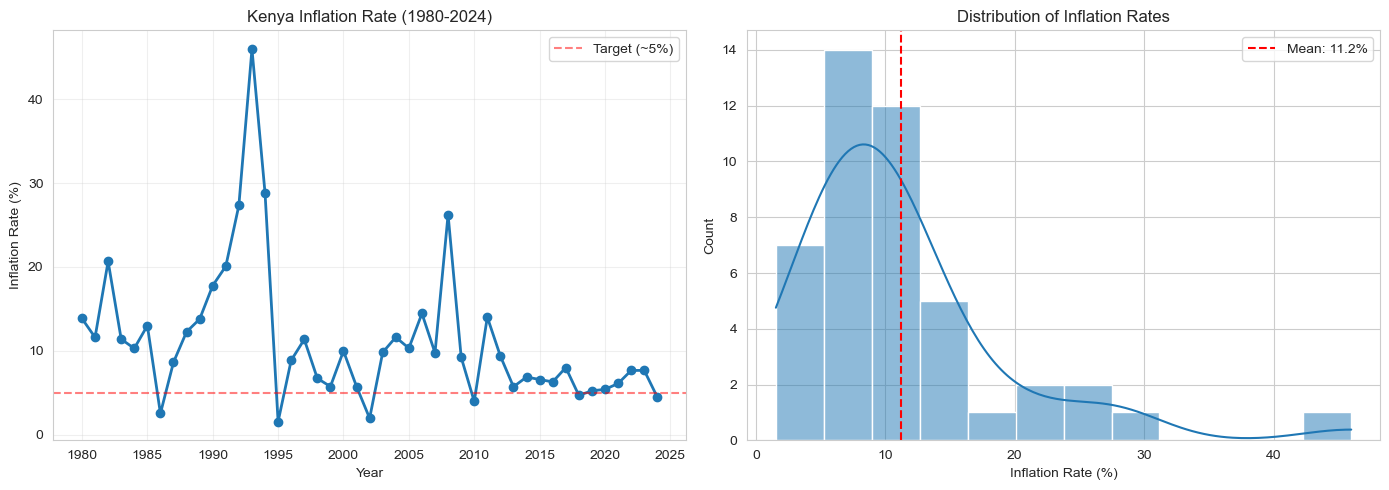

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Historical trend - use 'Year' column
axes[0].plot(kenya_inflation['Year'], kenya_inflation['Inflation_Rate'], 'o-', color='#1f77b4', linewidth=2, markersize=6)
axes[0].axhline(y=5, color='r', linestyle='--', alpha=0.5, label='Target (~5%)')
axes[0].set_title('Kenya Inflation Rate (1980-2024)', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Inflation Rate (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribution
sns.histplot(kenya_inflation['Inflation_Rate'], kde=True, color='#1f77b4', ax=axes[1])
axes[1].axvline(kenya_inflation['Inflation_Rate'].mean(), color='r', linestyle='--', 
                label=f'Mean: {kenya_inflation["Inflation_Rate"].mean():.1f}%')
axes[1].set_title('Distribution of Inflation Rates')
axes[1].set_xlabel('Inflation Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

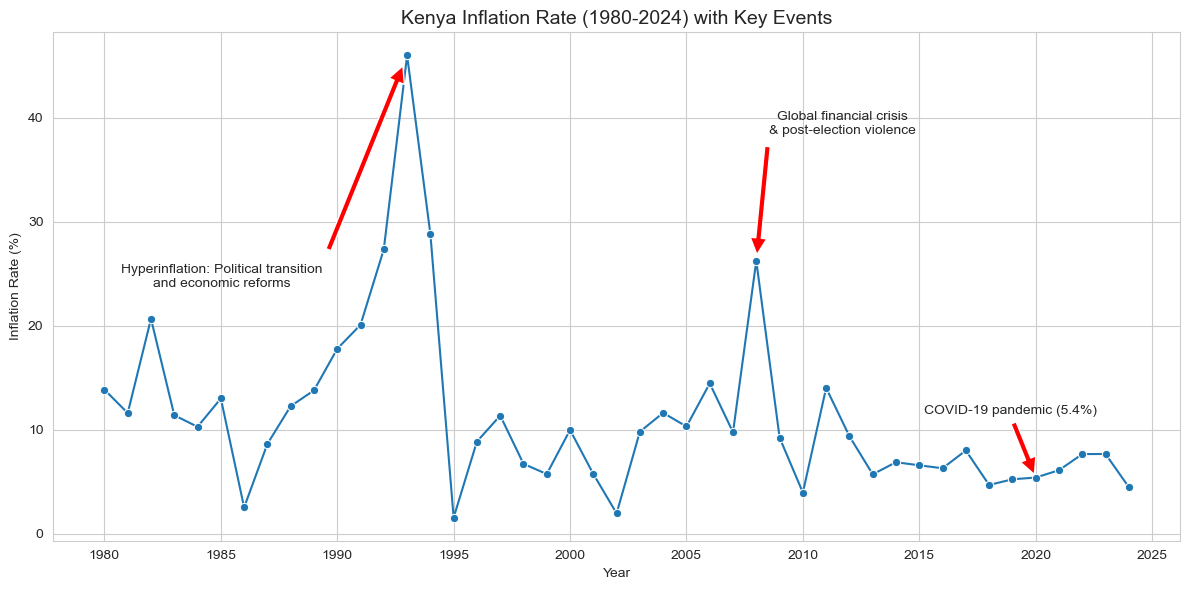

In [23]:
# Visualization 1: Annotated Line Chart with Event Markers
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.lineplot(x='Year', y='Inflation_Rate', data=kenya_inflation, marker='o', color='#1f77b4')

# Annotate key events
events = {
    '1993': ('Hyperinflation: Political transition\nand economic reforms', (0.15, 0.5)),
    '2008': ('Global financial crisis\n& post-election violence', (0.7, 0.8)),
    '2020': ('COVID-19 pandemic (5.4%)', (0.85, 0.25))
}

for year, (text, xy) in events.items():
    y_value = kenya_inflation[kenya_inflation['Year'].dt.year == int(year)]['Inflation_Rate'].values[0]
    ax.annotate(text,
                xy=(pd.to_datetime(year), y_value),
                xytext=xy,
                textcoords='axes fraction',
                arrowprops=dict(facecolor='red', shrink=0.05),
                ha='center')

plt.title('Kenya Inflation Rate (1980-2024) with Key Events', size=14)
plt.ylabel('Inflation Rate (%)')
plt.tight_layout()
plt.show()

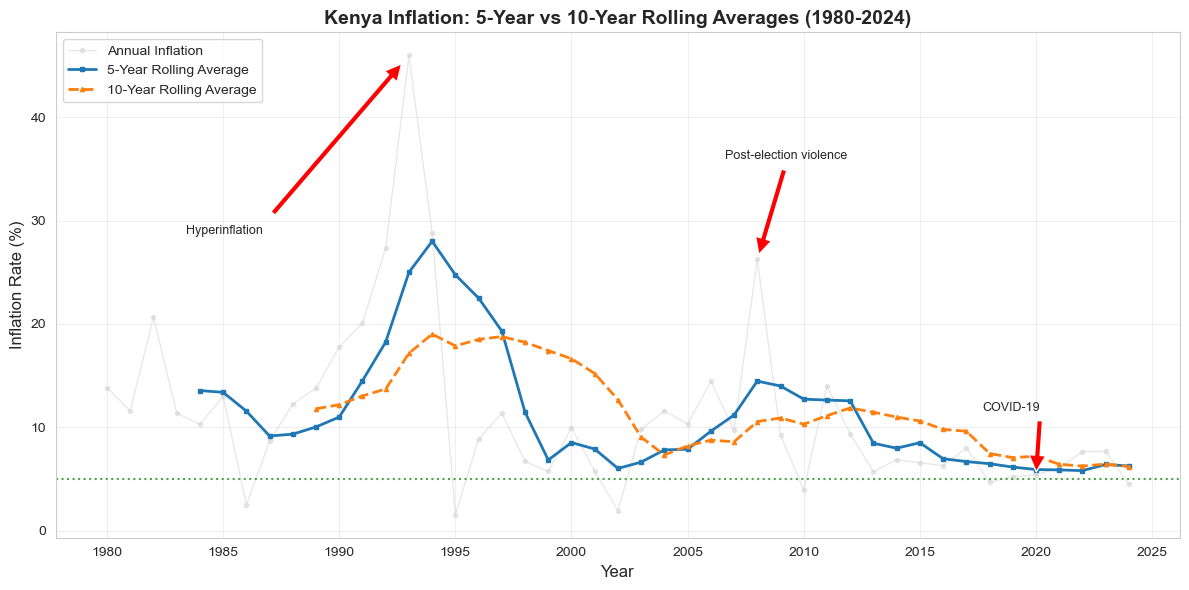

ROLLING AVERAGE COMPARISON
5-Year Rolling Avg (2020-2024): 6.06%
10-Year Rolling Avg (2015-2024): 7.72%

The 5-year average responds faster to recent changes,
while the 10-year average shows the longer-term trend.


In [24]:
# Visualization: 5-Year vs 10-Year Rolling Averages
plt.figure(figsize=(12, 6))

# Calculate both rolling averages
kenya_inflation['5-Year Rolling Avg'] = kenya_inflation['Inflation_Rate'].rolling(window=5).mean()
kenya_inflation['10-Year Rolling Avg'] = kenya_inflation['Inflation_Rate'].rolling(window=10).mean()

# Plot all three
plt.plot(kenya_inflation['Year'], kenya_inflation['Inflation_Rate'], 
         marker='o', linewidth=1, markersize=3, color='lightgray', alpha=0.5, label='Annual Inflation')
plt.plot(kenya_inflation['Year'], kenya_inflation['5-Year Rolling Avg'], 
         linewidth=2, color='#1f77b4', label='5-Year Rolling Average', marker='s', markersize=3)
plt.plot(kenya_inflation['Year'], kenya_inflation['10-Year Rolling Avg'], 
         linewidth=2, color='#ff7f0e', label='10-Year Rolling Average', marker='^', markersize=3, linestyle='--')

# Annotate key events
events = {
    '1993': ('Hyperinflation', (0.15, 0.6)),
    '2008': ('Post-election violence', (0.65, 0.75)),
    '2020': ('COVID-19', (0.85, 0.25))
}

for year, (text, xy) in events.items():
    year_dt = pd.to_datetime(f"{year}-01-01")
    y_value = kenya_inflation[kenya_inflation['Year'] == year_dt]['Inflation_Rate'].values[0]
    plt.annotate(text, xy=(year_dt, y_value), xytext=xy, textcoords='axes fraction',
                arrowprops=dict(facecolor='red', shrink=0.05), ha='center', fontsize=9)

plt.title('Kenya Inflation: 5-Year vs 10-Year Rolling Averages (1980-2024)', size=14, fontweight='bold')
plt.xlabel('Year', size=12)
plt.ylabel('Inflation Rate (%)', size=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=5, color='green', linestyle=':', alpha=0.7, label='Target (5%)')
plt.tight_layout()
plt.show()

# Print comparison
print("ROLLING AVERAGE COMPARISON")

print(f"5-Year Rolling Avg (2020-2024): {kenya_inflation['5-Year Rolling Avg'].tail(5).mean():.2f}%")
print(f"10-Year Rolling Avg (2015-2024): {kenya_inflation['10-Year Rolling Avg'].tail(10).mean():.2f}%")
print(f"\nThe 5-year average responds faster to recent changes,")
print(f"while the 10-year average shows the longer-term trend.")

In [25]:

result = adfuller(kenya_inflation['Inflation_Rate'].dropna())
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Stationary: {'Yes' if result[1] < 0.05 else 'No'}")

ADF Statistic: -3.5575
p-value: 0.0066
Stationary: Yes


Why: Time series forecasting requires stationary data (constant mean/variance over time)

Result: p-value = 0.0066 (< 0.05) → Data is stationary, no differencing needed

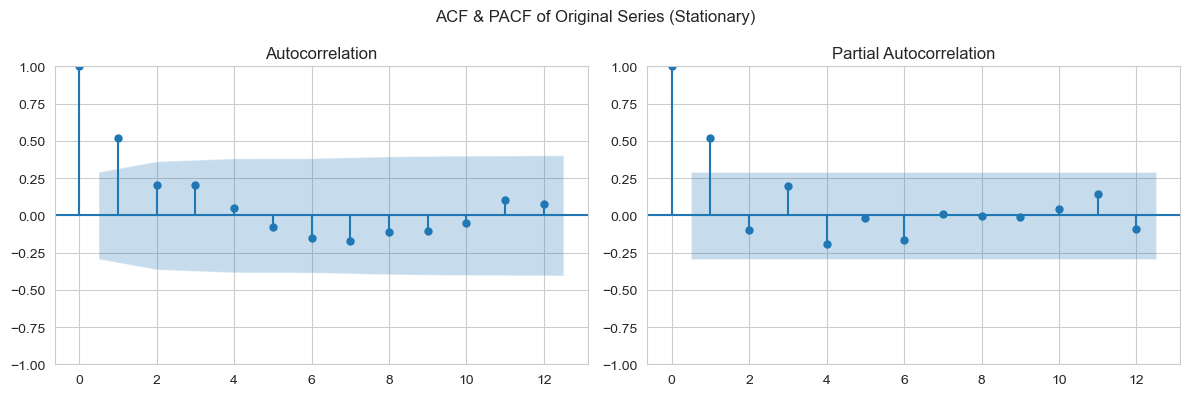

In [26]:
# ACF/PACF PLOTS (Original Series - No Differencing) 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(kenya_inflation['Inflation_Rate'], lags=12, ax=axes[0])
plot_pacf(kenya_inflation['Inflation_Rate'], lags=12, ax=axes[1], method='ywm')
plt.suptitle('ACF & PACF of Original Series (Stationary)')
plt.tight_layout()
plt.show()


In [27]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

auto_model = auto_arima(kenya_inflation['Inflation_Rate'], 
                        start_p=0, start_q=0, max_p=3, max_q=3,
                        seasonal=False, stepwise=True, trace=False)
print(f"\nOptimal ARIMA Order: {auto_model.order}")


Optimal ARIMA Order: (0, 0, 1)


In [28]:
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import pandas as pd
import numpy as np
# Prepare data
arima_df = kenya_inflation[['Year', 'Inflation_Rate']].copy()

# Train on 1980-2019 ONLY (same as Prophet)
train_mask = arima_df['Year'].dt.year <= 2019
train_data = arima_df[train_mask]['Inflation_Rate'].values

# Auto-tune to find best order
auto_model = auto_arima(
    train_data,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=False,
    stepwise=True,
    trace=True,  # Shows the search process
    information_criterion='aic'
)

best_order = auto_model.order
print(f"Optimal ARIMA order: {best_order}")

# Fit model on training data only (1980-2019)
model = ARIMA(train_data, order=best_order)
results = model.fit()
print(results.summary())

# Forecast 2025-2029
last_actual_year = kenya_inflation['Year'].dt.year.max()  # Gets 2024
forecast = results.forecast(steps=5)
forecast_years = [2025, 2026, 2027, 2028, 2029]

# Get confidence intervals
forecast_result = results.get_forecast(steps=5)
conf_int = forecast_result.conf_int()

# Display forecast
print("\n" + "="*50)
print(f"ARIMA{best_order} FORECAST (2025-2029)")
print("="*50)
for year, value, ci_lower, ci_upper in zip(forecast_years, forecast, conf_int[:, 0], conf_int[:, 1]):
    print(f"{year}: {value:.2f}% (95% CI: [{ci_lower:.1f}% - {ci_upper:.1f}%])")

# Save to CSV
arima_forecast_df = pd.DataFrame({
    'Year': forecast_years,
    'yhat': forecast.round(2),
    'yhat_lower': conf_int[:, 0].round(2),
    'yhat_upper': conf_int[:, 1].round(2)
})
arima_forecast_df.to_csv(r"arima_forecast.csv", index=False)

print("\n✅ Forecast saved to 'arima_forecast.csv'")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=329.439, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=285.392, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=300.491, Time=0.03 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=287.115, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=286.495, Time=0.04 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=287.311, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=278.453, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=287.948, Time=0.01 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=279.919, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=277.731, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=275.747, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=277.737, Time=0.08 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=279.605, Time=0.14 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 0.681 seconds
Optimal ARIMA order: (0, 0, 1)
    

In [29]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

# Prepare data
prophet_df = pd.DataFrame({
    'ds': pd.date_range(start='1980-01-01', periods=len(kenya_inflation), freq='YS'),
    'y': kenya_inflation['Inflation_Rate'].values
})

# Split data 
train = prophet_df[prophet_df['ds'].dt.year <= 2019]
validate = prophet_df[prophet_df['ds'].dt.year.between(2020, 2023)]
test = prophet_df[prophet_df['ds'].dt.year == 2024]

# Tuned Prophet model 
model_prophet = Prophet(
    changepoint_prior_scale=0.08,      # Balanced trend flexibility
    seasonality_prior_scale=0.5,       # Moderate seasonality
    yearly_seasonality=False,           # No yearly pattern in annual data
    seasonality_mode='additive',        # Best for inflation
    interval_width=0.95
)

# Train on 1980-2019 ONLY
model_prophet.fit(train)

# Validate on 2020-2023
val_forecast = model_prophet.predict(validate[['ds']])
val_mape = mean_absolute_percentage_error(validate['y'], val_forecast['yhat']) * 100
print(f"Validation MAPE (2020-2023): {val_mape:.2f}%")

# Test on 2024
test_forecast = model_prophet.predict(test[['ds']])
test_mape = mean_absolute_percentage_error(test['y'], test_forecast['yhat']) * 100
print(f"Test MAPE (2024): {test_mape:.2f}%")

# Forecast 2025-2029
future_dates = pd.date_range(start='2025-01-01', periods=5, freq='YS')
future = pd.DataFrame({'ds': future_dates})
forecast_prophet = model_prophet.predict(future)

# Results
prophet_forecast_df = forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
prophet_forecast_df['Year'] = prophet_forecast_df['ds'].dt.year

print("\n" + "="*50)
print("TUNED PROPHET FORECAST (2025-2029)")
print("="*50)
print(prophet_forecast_df[['Year', 'yhat', 'yhat_lower', 'yhat_upper']].round(2))

# Save
prophet_forecast_df.to_csv("prophet_forecast.csv", index=False)
print(f"\n✅ Average validation error: ±{val_mape:.1f}%")

12:20:17 - cmdstanpy - INFO - Chain [1] start processing
12:20:18 - cmdstanpy - INFO - Chain [1] done processing


Validation MAPE (2020-2023): 18.33%
Test MAPE (2024): 36.89%

TUNED PROPHET FORECAST (2025-2029)
   Year  yhat  yhat_lower  yhat_upper
0  2025  5.92       -9.71       22.36
1  2026  5.69       -9.35       22.11
2  2027  5.46       -9.69       21.75
3  2028  5.23       -9.49       20.07
4  2029  4.99       -9.96       20.26

✅ Average validation error: ±18.3%


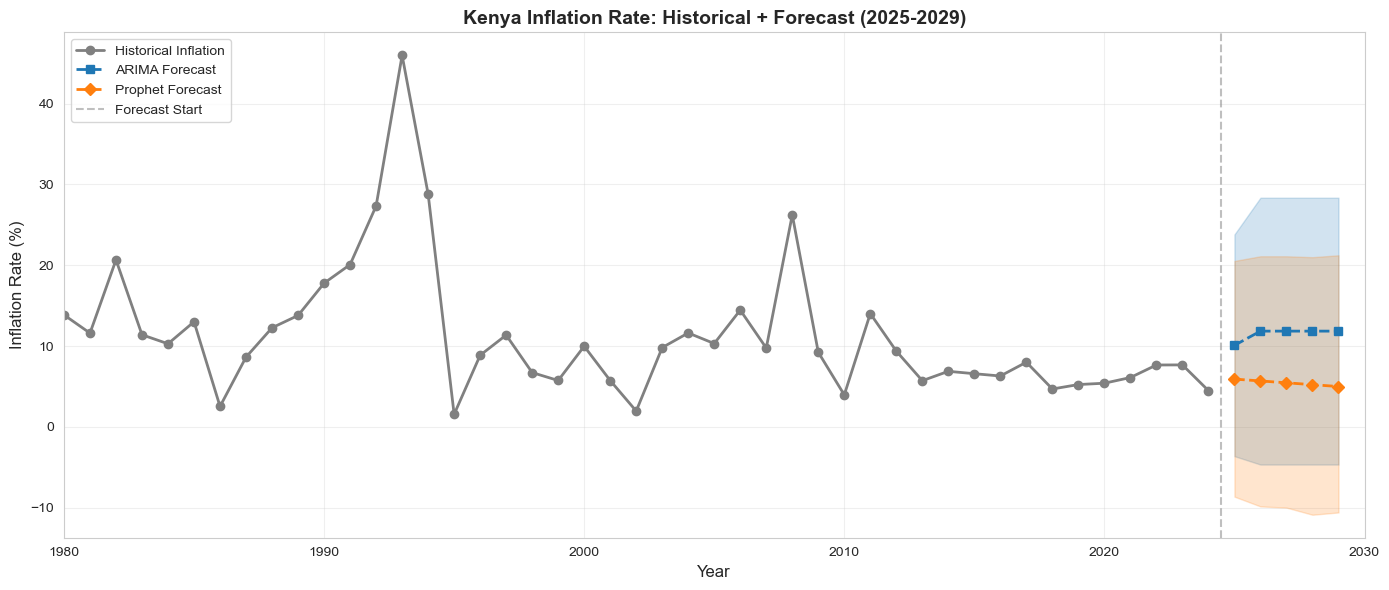

In [24]:
plt.figure(figsize=(14, 6))

# Historical Inflation data (1980-2024)
historical_years = kenya_inflation['Year'].dt.year
plt.plot(historical_years, kenya_inflation['Inflation_Rate'], 
         label='Historical Inflation', marker='o', color='gray', linewidth=2)

# ARIMA Forecast (2025-2029)
plt.plot(arima_forecast_df['Year'], arima_forecast_df['yhat'], 
         '--s', label='ARIMA Forecast', color='#1f77b4', linewidth=2, markersize=6)
plt.fill_between(arima_forecast_df['Year'], 
                 arima_forecast_df['yhat_lower'], 
                 arima_forecast_df['yhat_upper'], 
                 color='#1f77b4', alpha=0.2)

# Prophet Forecast (2025-2029)
plt.plot(prophet_forecast_df['Year'], prophet_forecast_df['yhat'], 
         '--D', label='Prophet Forecast', color='#ff7f0e', linewidth=2, markersize=6)
plt.fill_between(prophet_forecast_df['Year'], 
                 prophet_forecast_df['yhat_lower'], 
                 prophet_forecast_df['yhat_upper'], 
                 color='#ff7f0e', alpha=0.2)

# Add vertical line separating historical from forecast
plt.axvline(x=2024.5, color='gray', linestyle='--', alpha=0.5, label='Forecast Start')

plt.title("Kenya Inflation Rate: Historical + Forecast (2025-2029)", fontsize=14, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Inflation Rate (%)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1980, 2030)
plt.tight_layout()
plt.show()